In [1]:
import numpy as np
import matplotlib.pyplot as plt
from FirstOrderAcousticForwardSolver import FirstOrderAcousticForwardSolver
from source import ricker
from mpl_toolkits.axes_grid1 import make_axes_locatable
from plot_wiggle import WigglePlotter

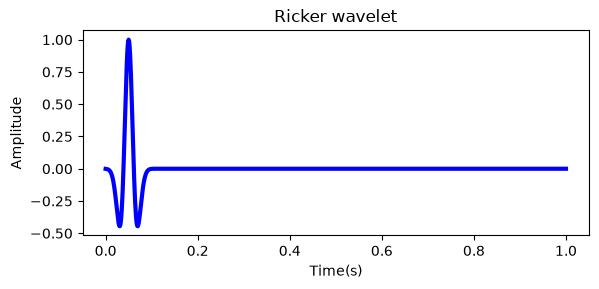

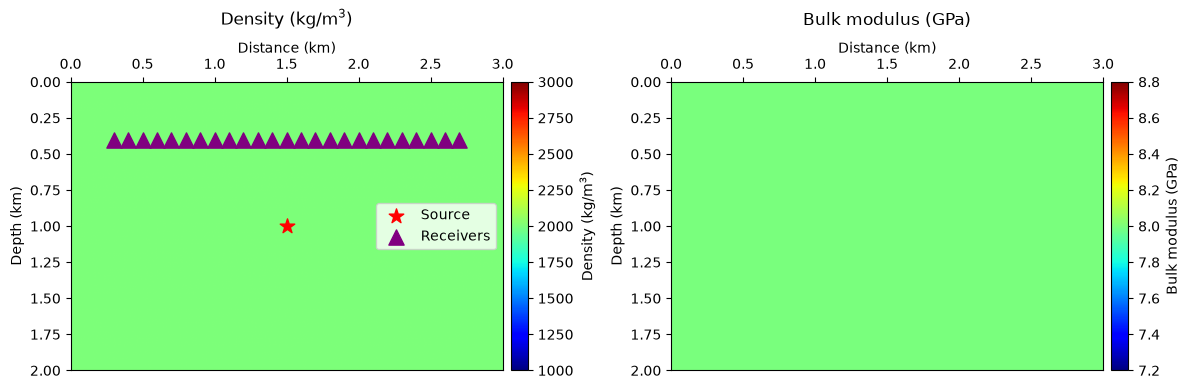

In [2]:
# ===================================================
# Basic parameters
# ===================================================
nx = 301
nz = 201
dx = 10.0
dz = 10.0
dt = 0.001
xmax = (nx-1)*dx
zmax = (nz-1)*dz
tmax = 1.0
nt = int(tmax / dt) + 1
t = np.arange(nt) * dt
# ===================================================
# Source (Ricker wavelet)
# ===================================================
ix_src = nx // 2
iz_src = nz // 2
f0 = 20.0
t0 = 1.0 / f0
wavelet = ricker(t, f0, t0)
fig, ax_src = plt.subplots(figsize=(6,3))
ax_src.plot(t,wavelet,linewidth=3,color='blue')
ax_src.set_xlabel('Time(s)')
ax_src.set_ylabel('Amplitude')
ax_src.set_title('Ricker wavelet')
plt.tight_layout()
plt.show()
# ===================================================
# Receivers
# ===================================================
ix_receivers = np.arange(30,nx - 30,10,dtype=np.int64)
iz_receivers = np.full(len(ix_receivers),40,dtype=np.int64)
# ===================================================
# Model (rho and bulk)
# ===================================================
vp = np.full((nz, nx),2000.0,dtype=np.float64)
rho = np.full((nz, nx),2000.0,dtype=np.float64)
bulk = rho * vp**2

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12, 4))
im1 = ax1.imshow(
    rho,
    extent=[0, xmax/1e3, zmax/1e3, 0],
    vmin=1000,
    vmax=3000,
    cmap="jet",
    aspect="auto"
)
ax1.scatter(ix_src*dx/1e3,iz_src*dz/1e3,color='red',marker='*',s=120,label='Source')
ax1.scatter(ix_receivers*dx/1e3,iz_receivers*dz/1e3,color='purple',marker='^',s=120,label='Receivers')
# x-axis on the top
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position("top")
ax1.set_xlabel("Distance (km)")
ax1.set_ylabel("Depth (km)")
ax1.set_title("Density (kg/m$^3$)", pad=12)
ax1.legend(loc='right')
# Colorbar
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right",size="4%",pad=0.08)
cbar1 = fig.colorbar(im1,cax=cax1)
cbar1.set_label("Density (kg/m$^3$)")

# ============================================================
# 2. Bulk modulus model
# ============================================================
im2 = ax2.imshow(
    bulk/1e9,
    extent=[0, xmax/1e3, zmax/1e3, 0],
    cmap="jet",
    aspect="auto"
)
# x-axis on the top
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position("top")
ax2.set_xlabel("Distance (km)")
ax2.set_ylabel("Depth (km)")
ax2.set_title("Bulk modulus (GPa)", pad=12)
# Colorbar
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right",size="4%",pad=0.08)
cbar2 = fig.colorbar(im2,cax=cax2)
cbar2.set_label("Bulk modulus (GPa)")

plt.tight_layout()
plt.show()


In [3]:
# ============================================================
# Solver
# ============================================================
solver = FirstOrderAcousticForwardSolver(
    rho=rho,
    bulk=bulk,
    dx=dx,
    dz=dz,
    dt=dt,
    order=8,
)

solver.set_source(wavelet=wavelet,ix=ix_src,iz=iz_src,)
solver.set_receivers(ix=ix_receivers,iz=iz_receivers,)

solver.set_boundary(boundary_type="dirichlet")
result_dirichlet = solver.forward(snapshot_times=[0.2,0.4,0.6,0.8,])
seismogram_dirichlet = result_dirichlet.seismogram
snapshots_dirichlet = result_dirichlet.snapshots
print("Seismogram shape =", seismogram_dirichlet.shape)
print("Snapshots shape  =", snapshots_dirichlet.shape)

solver.set_boundary(boundary_type="pml",n_abs=40,reflection=1e-6,power=2,)
result_pml = solver.forward(snapshot_times=[0.2,0.4,0.6,0.8,])
seismogram_pml = result_pml.seismogram
snapshots_pml = result_pml.snapshots
print("Seismogram shape =", seismogram_pml.shape)
print("Snapshots shape  =", snapshots_pml.shape)

Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s
Time step: 500 / 1001   Time: 0.5 s
Time step: 600 / 1001   Time: 0.6 s
Time step: 700 / 1001   Time: 0.7000000000000001 s
Time step: 800 / 1001   Time: 0.8 s
Time step: 900 / 1001   Time: 0.9 s
Time step: 1000 / 1001   Time: 1.0 s
Seismogram shape = (1001, 25)
Snapshots shape  = (4, 201, 301)
Time step: 100 / 1001   Time: 0.1 s
Time step: 200 / 1001   Time: 0.2 s
Time step: 300 / 1001   Time: 0.3 s
Time step: 400 / 1001   Time: 0.4 s
Time step: 500 / 1001   Time: 0.5 s
Time step: 600 / 1001   Time: 0.6 s
Time step: 700 / 1001   Time: 0.7000000000000001 s
Time step: 800 / 1001   Time: 0.8 s
Time step: 900 / 1001   Time: 0.9 s
Time step: 1000 / 1001   Time: 1.0 s
Seismogram shape = (1001, 25)
Snapshots shape  = (4, 201, 301)


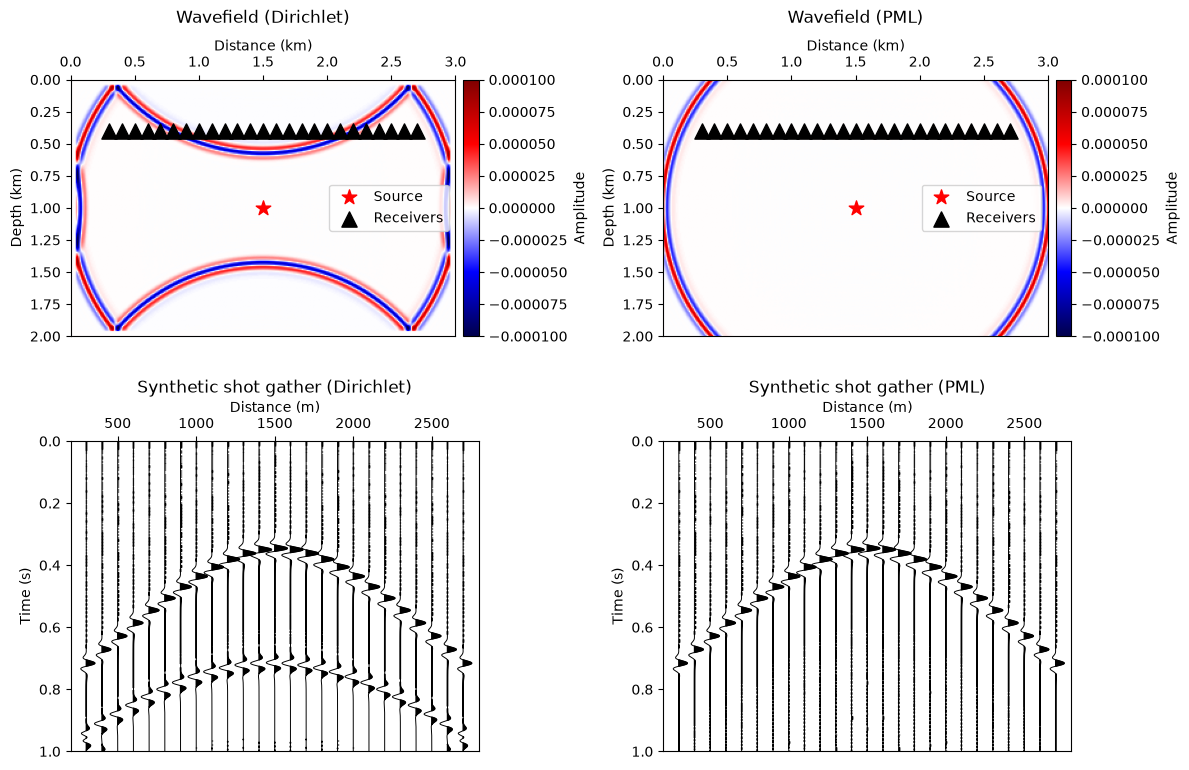

In [4]:
fig, axes = plt.subplots(2,2,figsize=(12, 8))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]
# Wavefield dirichlet
ax1.scatter(ix_src*dx/1e3,iz_src*dz/1e3,color='red',marker='*',s=120,label='Source')
ax1.scatter(ix_receivers*dx/1e3,iz_receivers*dz/1e3,color='black',marker='^',s=120,label='Receivers')
im1 = ax1.imshow(
    snapshots_dirichlet[3],
    extent = [0, xmax/1e3, zmax/1e3, 0],
    aspect='equal',
    vmin = -1e-4,
    vmax = 1e-4,
    cmap = 'seismic',
)
# x-axis on the top
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position("top")
ax1.set_xlabel("Distance (km)")
ax1.set_ylabel("Depth (km)")
ax1.set_title("Wavefield (Dirichlet)", pad=12)
ax1.legend(loc='right')
# Colorbar
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right",size="4%",pad=0.08)
cbar1 = fig.colorbar(im1,cax=cax1)
cbar1.set_label("Amplitude")

# Wavefield pml
ax2.scatter(ix_src*dx/1e3,iz_src*dz/1e3,color='red',marker='*',s=120,label='Source')
ax2.scatter(ix_receivers*dx/1e3,iz_receivers*dz/1e3,color='black',marker='^',s=120,label='Receivers')
im2 = ax2.imshow(
    snapshots_pml[3],
    extent = [0, xmax/1e3, zmax/1e3, 0],
    aspect='equal',
    vmin = -1e-4,
    vmax = 1e-4,
    cmap = 'seismic',
)
# x-axis on the top
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position("top")
ax2.set_xlabel("Distance (km)")
ax2.set_ylabel("Depth (km)")
ax2.set_title("Wavefield (PML)", pad=12)
ax2.legend(loc='right')
# Colorbar
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right",size="4%",pad=0.08)
cbar2 = fig.colorbar(im2,cax=cax2)
cbar2.set_label("Amplitude")

# Seismogram dirichlet
time = np.arange(seismogram_dirichlet.shape[0]) * dt
distance = ix_receivers * dx
wiggle1 = WigglePlotter(
    seismogram=seismogram_dirichlet,
    time=time,
    distance=distance,
)
wiggle1.plot(
    ax=ax3,
    scale=0.8,
    normalize="global",
    fill=True,
    xlabel="Distance (m)",
    ylabel="Time (s)",
    title="Synthetic shot gather (Dirichlet)"
)

# Seismogram pml
time = np.arange(seismogram_pml.shape[0]) * dt
distance = ix_receivers * dx
wiggle1 = WigglePlotter(
    seismogram=seismogram_pml,
    time=time,
    distance=distance,
)
wiggle1.plot(
    ax=ax4,
    scale=0.8,
    normalize="global",
    fill=True,
    xlabel="Distance (m)",
    ylabel="Time (s)",
    title="Synthetic shot gather (PML)"
)

plt.tight_layout()
plt.show()